[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lijingwang/Machine_Learning_Hydrology/blob/main/01_SHAP.ipynb)

# 01 — SHAP: Explaining MLP Predictions
**ERTH 4750/5750 — Machine Learning and Numerical Modeling in Hydrology | University of Connecticut**

---

## Learning Objectives
- Understand what SHAP values measure and how they are computed
- Interpret beeswarm, waterfall, and dependence plots
- Identify dominant controls on Q90 across 671 CAMELS catchments
- Map spatial patterns of feature importance

In [1]:
# Google Colab setup (skip if running locally)
!pip install -q numpy pandas matplotlib scikit-learn torch pygeohydro shap plotly
# Download helper functions
import os
if not os.path.exists("helpers.py"):
    !wget -q https://raw.githubusercontent.com/lijingwang/Machine_Learning_Hydrology/main/helpers.py

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pygeohydro as gh
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | SHAP {shap.__version__} | device: {device}')

PyTorch 2.10.0 | SHAP 0.51.0 | device: cpu


---
## Part 1 — What is SHAP?

### 1.1 The Attribution Problem

Our MLP takes 28 catchment attributes and outputs a Q90 prediction. For any given catchment we want to ask: **which features pushed this prediction up or down, and by how much?**

This is the **attribution problem** — splitting the model's output into individual feature contributions.

---

### 1.2 Simple Version — The Core Idea

Think of the 28 features as players on a team. The team's "score" is the model's prediction. SHAP asks a fair question:

> *"If I add feature $j$ to a randomly assembled team of other features, how much does the score change — on average across every possible team?"*

That average change is the **SHAP value** $\phi_j$.

**Key properties:**
- $\phi_j > 0$ → feature **raised** Q90 above the average prediction
- $\phi_j < 0$ → feature **lowered** Q90 below the average prediction
- All SHAP values **sum exactly** to the prediction minus the baseline: nothing is left unexplained

**Concrete example:** Baseline (average Q90 across all catchments) = 0.22 mm/day. Model predicts 0.35 mm/day for a wet, forested catchment. The gap of +0.13 mm/day is fully explained:

$$\underbrace{\phi_{p\_mean}}_{+0.08} + \underbrace{\phi_{aridity}}_{+0.03} + \underbrace{\phi_{soil\_depth}}_{+0.04} + \cdots + \underbrace{\phi_{lai\_max}}_{-0.02} = +0.13 \text{ mm/day}$$

Units are always **mm/day** — the same as the prediction. Feature importance is directly interpretable.

---

### 1.3 Hard Version — The Math

#### The Shapley Formula

$$\boxed{\phi_j = \sum_{S \subseteq F \setminus \{j\}} \frac{|S|!\,(|F|-|S|-1)!}{|F|!} \left[\, f(S \cup \{j\}) - f(S) \,\right]}$$

| Symbol | Meaning |
|--------|---------|
| $F$ | All features |
| $S$ | A subset of features not including $j$ |
| $f(S \cup \{j\}) - f(S)$ | How much the prediction changes when you add feature $j$ to subset $S$ |
| $\frac{|S|!\,(|F|-|S|-1)!}{|F|!}$ | **Weight** — explained below |

---

#### What is the Weight?

Think of all $|F|!$ possible **orderings** (permutations) of the features. In each ordering, feature $j$ sits at some position, and the features that come **before** it form a subset $S$.

The weight $\dfrac{|S|!\,(|F|-|S|-1)!}{|F|!}$ counts the **fraction of all orderings where exactly the features in $S$ appear before $j$**:

| Part | What it counts |
|------|----------------|
| $|S|!$ | Ways to arrange the $|S|$ features **before** $j$ |
| $(|F|-|S|-1)!$ | Ways to arrange the remaining features **after** $j$ |
| $|F|!$ | Total orderings (normalises to a fraction) |

**Bottom line:** the weight ensures every ordering of features is counted equally (each gets probability $1/|F|!$), so $\phi_j$ is the **average marginal contribution of feature $j$ across all possible orderings** of features.

---

#### Methods for Computing SHAP Values

| Method | Works With | Approach |
|--------|-----------|----------|
| **Exact / KernelSHAP** | Any model | Samples random feature subsets, fits weighted linear model to attribute contributions. Slow but model-agnostic. |
| **TreeSHAP** | Tree models (XGBoost, RF, LightGBM) | Exact, polynomial-time algorithm exploiting tree structure. Very fast. |
| **GradientExplainer** | Differentiable models (neural nets) | Blends input toward reference, averages gradients over blend weights and background samples. |
| **DeepExplainer** | Neural nets | Propagates SHAP values backward through layers using DeepLIFT rules. Faster than GradientExplainer but less exact. |
| **LinearExplainer** | Linear models | Closed-form solution using feature covariance. Exact and instant. |
| **PermutationSHAP** | Any model | Permutes features in random orderings, measures prediction change. Simple but slow. |

For our MLP we use **GradientExplainer**, which is the most theoretically grounded choice for neural networks.

---

#### The Guarantee

No matter which method is used, SHAP values always sum to exactly the gap between the prediction and the baseline:

$$\phi_{p\_mean} + \phi_{aridity} + \cdots + \phi_{geol\_permeability} = f(x) - \bar{f}$$

---
## Part 2 — Load Data & Train Model

We repeat the same setup as `00_MLP.ipynb` so this notebook is self-contained.

In [3]:
camels, ts = gh.get_camels()

area_m2 = camels['area_gages2'].values * 1e6
q_mmday = ts['discharge'].values.T * 0.0283168 / area_m2[:, None] * 86400 * 1000

camels = camels.copy()
camels['Q90'] = np.nanpercentile(q_mmday, 10, axis=1)  # 10th pctile = exceeded 90% of time

print(f"Catchments: {len(camels)}  |  Q90 median: {camels['Q90'].median():.4f} mm/day")

Catchments: 671  |  Q90 median: 0.1171 mm/day


In [4]:
feature_cols = [
    # Climate (9)
    'p_mean', 'pet_mean', 'aridity', 'p_seasonality', 'frac_snow',
    'high_prec_freq', 'high_prec_dur', 'low_prec_freq', 'low_prec_dur',
    # Topography (3)
    'elev_mean', 'slope_mean', 'area_gages2',
    # Vegetation (5)
    'frac_forest', 'lai_max', 'lai_diff', 'gvf_max', 'gvf_diff',
    # Soil (7)
    'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity',
    'max_water_content', 'sand_frac', 'silt_frac', 'clay_frac',
    # Geology (4)
    'soil_depth_pelletier', 'carbonate_rocks_frac', 'geol_permeability', 'geol_porostiy',
]

feat_group = {}
for c in feature_cols[:9]:   feat_group[c] = 'Climate'
for c in feature_cols[9:12]: feat_group[c] = 'Topography'
for c in feature_cols[12:17]:feat_group[c] = 'Vegetation'
for c in feature_cols[17:24]:feat_group[c] = 'Soil'
for c in feature_cols[24:]:  feat_group[c] = 'Geology'

GROUP_COLORS = {'Climate':'#4e79a7','Topography':'#f28e2b',
                'Soil':'#59a14f','Geology':'#e15759','Vegetation':'#76b7b2'}

target = 'Q90'
data   = camels[feature_cols + [target]].dropna()

X       = data[feature_cols].values
y       = data[target].values.reshape(-1, 1)
idx_all = np.arange(len(data))

# ── 70 / 10 / 20 split — identical to 00_MLP (random_state=10) ───────────────
X_temp, X_test, y_temp, y_test, idx_temp, idx_test = train_test_split(
    X, y, idx_all, test_size=0.20, random_state=10)
X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X_temp, y_temp, idx_temp, test_size=0.125, random_state=10)   # 0.125×0.80 = 0.10

scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)

X_train_sc = scaler_X.transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)
y_train_sc = scaler_y.transform(y_train)
y_val_sc   = scaler_y.transform(y_val)
y_test_sc  = scaler_y.transform(y_test)

input_dim = X_train_sc.shape[1]
print(f"Train: {len(X_train_sc)} ({len(X_train_sc)/len(data)*100:.0f}%) | "
      f"Val: {len(X_val_sc)} ({len(X_val_sc)/len(data)*100:.0f}%) | "
      f"Test: {len(X_test_sc)} ({len(X_test_sc)/len(data)*100:.0f}%) | "
      f"Features: {input_dim}")

Train: 467 (70%) | Val: 67 (10%) | Test: 134 (20%) | Features: 28


Architecture : 28 → 16 → 16 → 1
Parameters   : 753


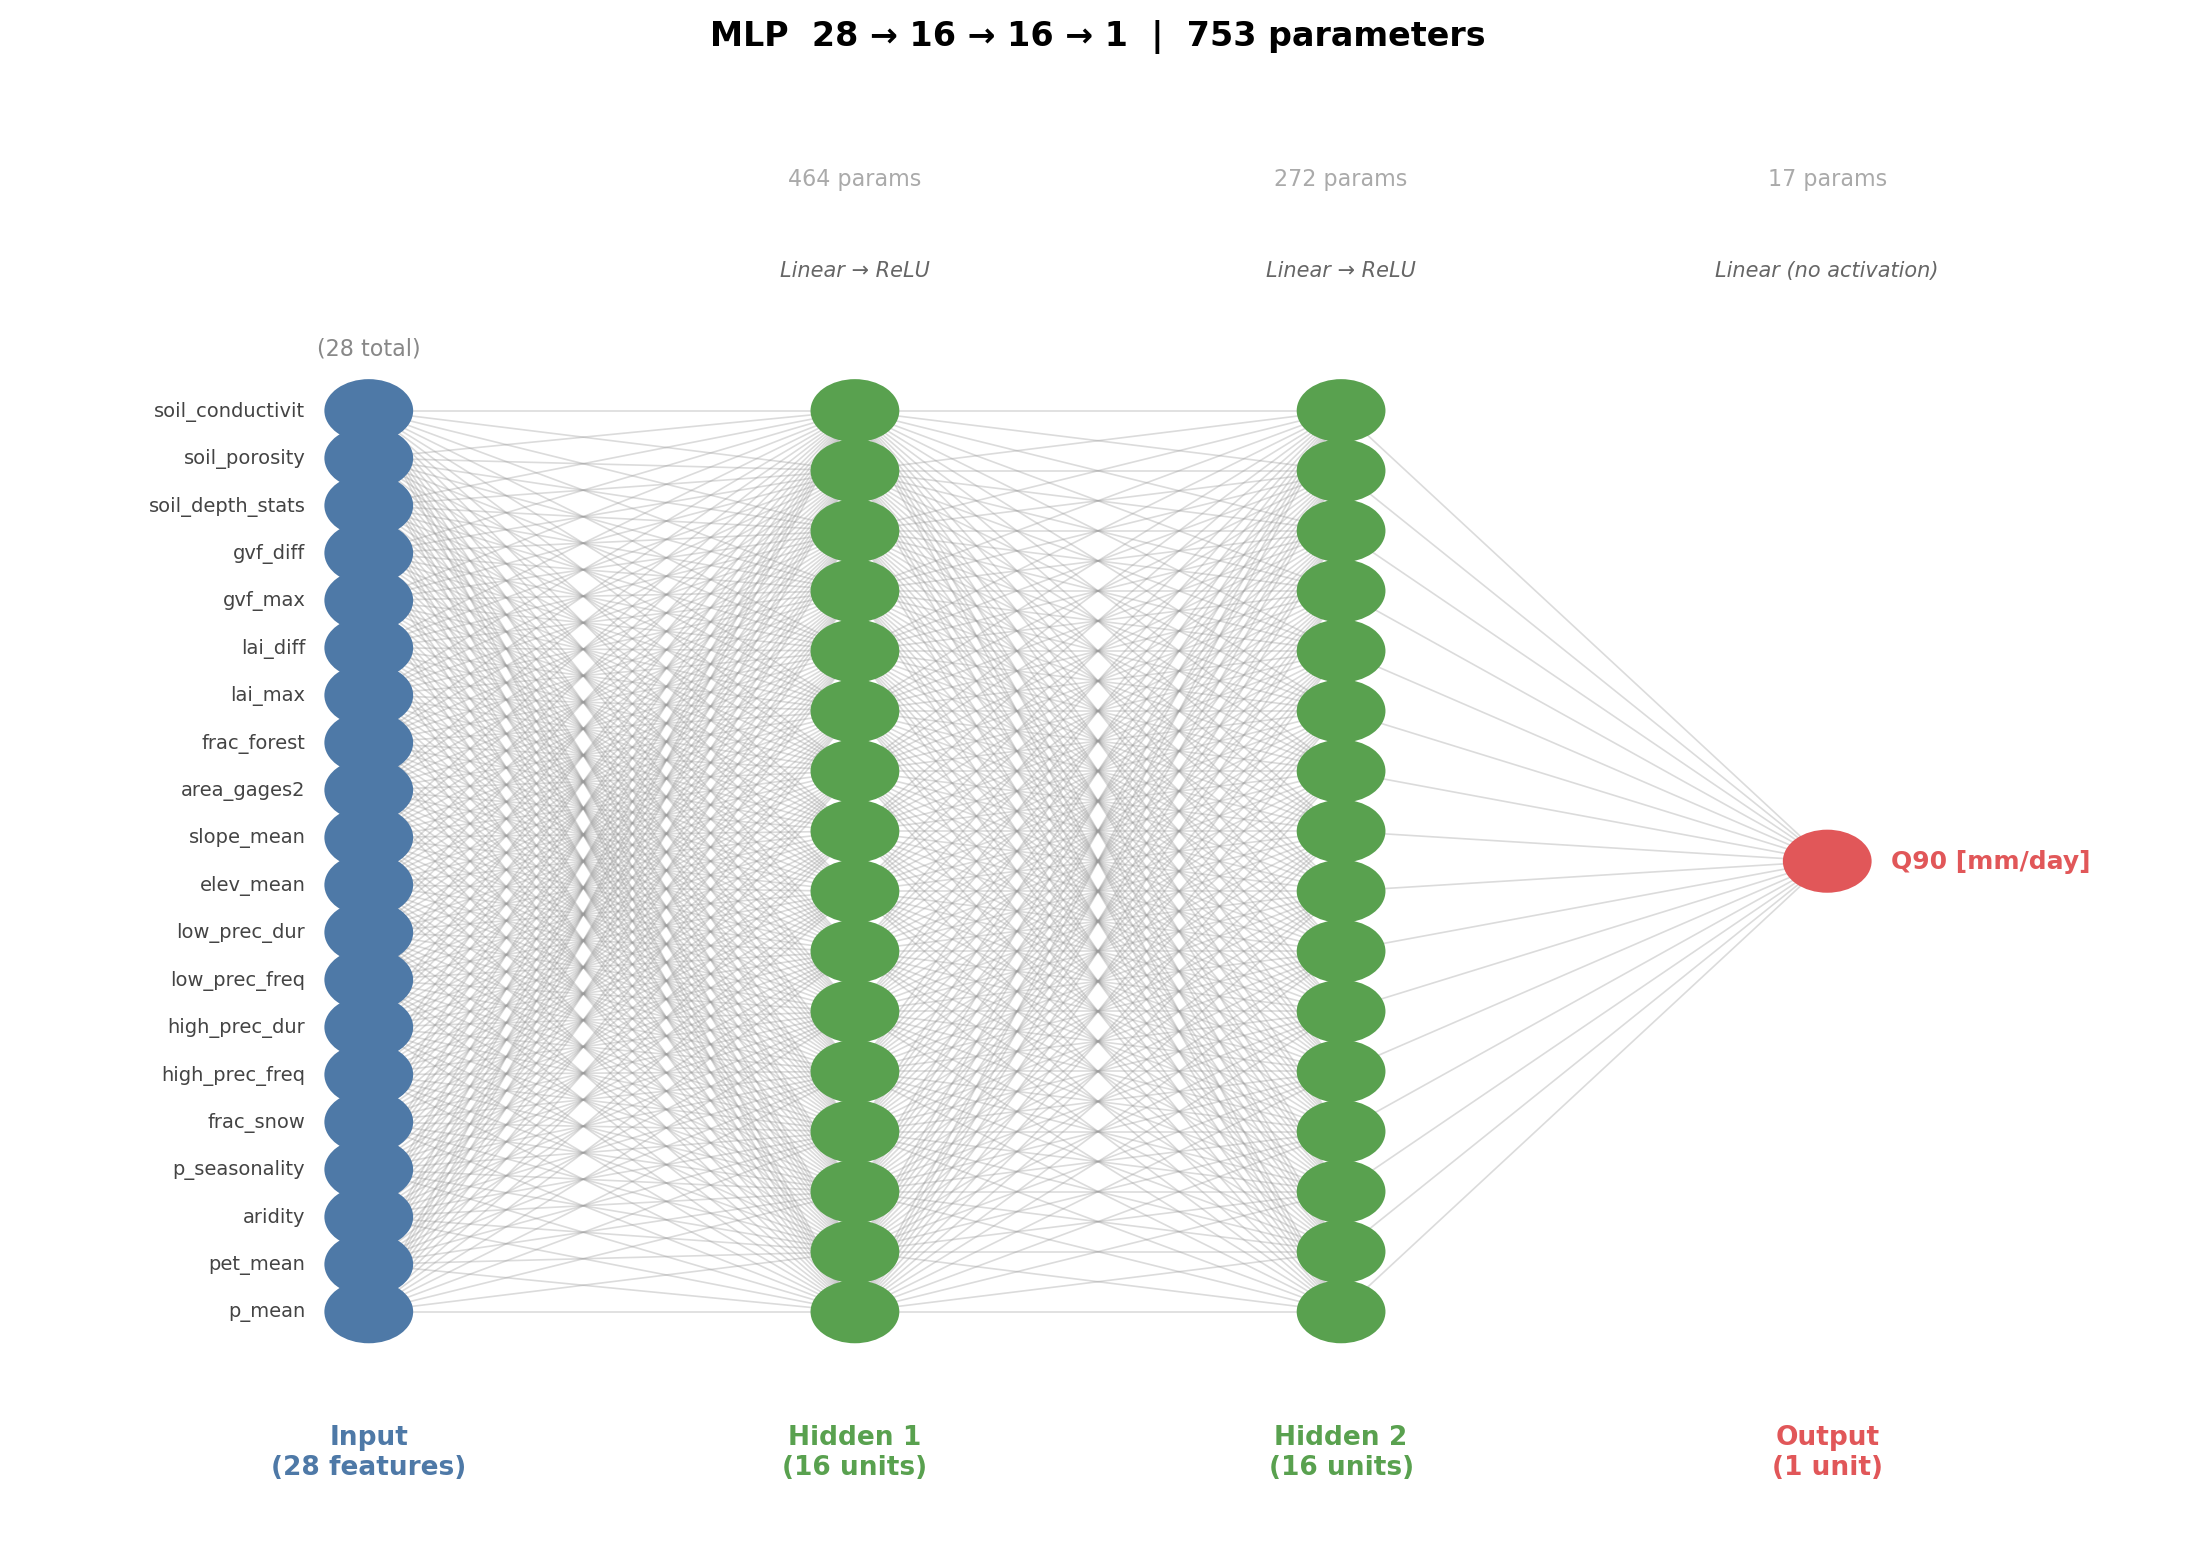

Architecture : 28 → 16 → 16 → 1
Total parameters : 753
Early stopping at epoch 56
Best val loss: 0.2527  |  Test RMSE = 0.2273 mm/day  |  R² = 0.514


In [5]:
from helpers import draw_network

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims):
        super().__init__()
        layers, in_dim = [], input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

# ── Q5 & Q6: Plug in your best hyperparameters from Q4 (00_MLP Part 8) ────────
# Replace the values below with the best configuration you found via cross-validation.
HIDDEN_DIMS    = [16, 16]   # ← e.g. [16, 16] or [32, 32, 32]
LR             = 1e-3           # ← e.g. 1e-3 or 5e-4
BATCH_SIZE     = 32             # ← your chosen batch size from Q3
# ─────────────────────────────────────────────────────────────────────────────
EPOCHS         = 500
EARLY_STOPPING = True
PATIENCE       = 30

model = MLP(input_dim, HIDDEN_DIMS).to(device)
print(f"Architecture : {input_dim} → {' → '.join(map(str, HIDDEN_DIMS))} → 1")
print(f"Parameters   : {sum(p.numel() for p in model.parameters()):,}")
draw_network(input_dim, HIDDEN_DIMS, feature_cols)

X_tr = torch.FloatTensor(X_train_sc).to(device)
y_tr = torch.FloatTensor(y_train_sc).to(device)
X_vl = torch.FloatTensor(X_val_sc).to(device)
y_vl = torch.FloatTensor(y_val_sc).to(device)
X_te = torch.FloatTensor(X_test_sc).to(device)
y_te = torch.FloatTensor(y_test_sc).to(device)

loader    = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.MSELoss()

best_val, patience_cnt, best_state = np.inf, 0, None
for epoch in range(EPOCHS):
    model.train()
    for Xb, yb in loader:
        optimizer.zero_grad()
        criterion(model(Xb), yb).backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        vl = criterion(model(X_vl), y_vl).item()
    if vl < best_val:
        best_val, patience_cnt = vl, 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_cnt += 1
    if EARLY_STOPPING and patience_cnt >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    y_pred = scaler_y.inverse_transform(model(X_te).cpu().numpy()).flatten()
y_true = scaler_y.inverse_transform(y_te.cpu().numpy()).flatten()
rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
r2   = r2_score(y_true, y_pred)
print(f"Best val loss: {best_val:.4f}  |  Test RMSE = {rmse:.4f} mm/day  |  R² = {r2:.3f}")

---
## Part 3 — Compute SHAP Values

`GradientExplainer` needs a **background dataset** — a sample of training points that represents the baseline distribution $E[f(X)]$. The SHAP value for feature $j$ then measures how much that feature's value pushes the prediction away from what we'd expect on average.

In [6]:
np.random.seed(40)
bg_idx = np.random.choice(len(X_train_sc), size=150, replace=False)
bg_t   = torch.FloatTensor(X_train_sc[bg_idx]).to(device)

model.eval()
explainer = shap.GradientExplainer(model, bg_t)

X_te_t = torch.FloatTensor(X_test_sc).to(device)
sv_raw = explainer.shap_values(X_te_t)

# GradientExplainer may return list or array; squeeze output dim → (n_test, n_features)
sv_raw = np.array(sv_raw[0] if isinstance(sv_raw, list) else sv_raw)
if sv_raw.ndim == 3:
    sv_raw = sv_raw.squeeze(-1)   # (n_test, n_features, 1) → (n_test, n_features)

# Rescale from normalised output space to mm/day
sv = sv_raw * scaler_y.scale_[0]   # (n_test, n_features)

baseline = scaler_y.mean_[0]

print(f"SHAP array shape : {sv.shape}  (test catchments × features)")
print(f"Baseline Q90     : {baseline:.4f} mm/day")
print(f"\nMean |SHAP| ranking:")
order = np.argsort(np.abs(sv).mean(axis=0))[::-1]
for rank, i in enumerate(order, 1):
    print(f"  {rank:2d}. {feature_cols[i]:<30}  {np.abs(sv[:, i]).mean():.5f} mm/day")

SHAP array shape : (134, 28)  (test catchments × features)
Baseline Q90     : 0.2221 mm/day

Mean |SHAP| ranking:
   1. low_prec_freq                   0.05271 mm/day
   2. gvf_diff                        0.05052 mm/day
   3. p_mean                          0.04779 mm/day
   4. slope_mean                      0.04039 mm/day
   5. geol_permeability               0.02585 mm/day
   6. p_seasonality                   0.02166 mm/day
   7. silt_frac                       0.01970 mm/day
   8. elev_mean                       0.01697 mm/day
   9. clay_frac                       0.01436 mm/day
  10. carbonate_rocks_frac            0.01398 mm/day
  11. soil_depth_pelletier            0.01392 mm/day
  12. high_prec_freq                  0.01314 mm/day
  13. high_prec_dur                   0.01281 mm/day
  14. frac_forest                     0.01132 mm/day
  15. frac_snow                       0.01078 mm/day
  16. sand_frac                       0.01066 mm/day
  17. geol_porostiy                   

In [7]:
# Build a shap.Explanation object for the modern plotting API
# data = raw (un-normalized) feature values so axis ticks are interpretable
shap_exp = shap.Explanation(
    values        = sv,
    base_values   = np.full(len(sv), baseline),
    data          = X_test,                      # raw feature values
    feature_names = feature_cols
)

---
## Part 4 — Global Explanations

### 4.1 Mean |SHAP| Bar Chart

The simplest global summary: average the absolute SHAP value of each feature across all **test catchments**. A larger bar means the feature changes predictions more, on average.

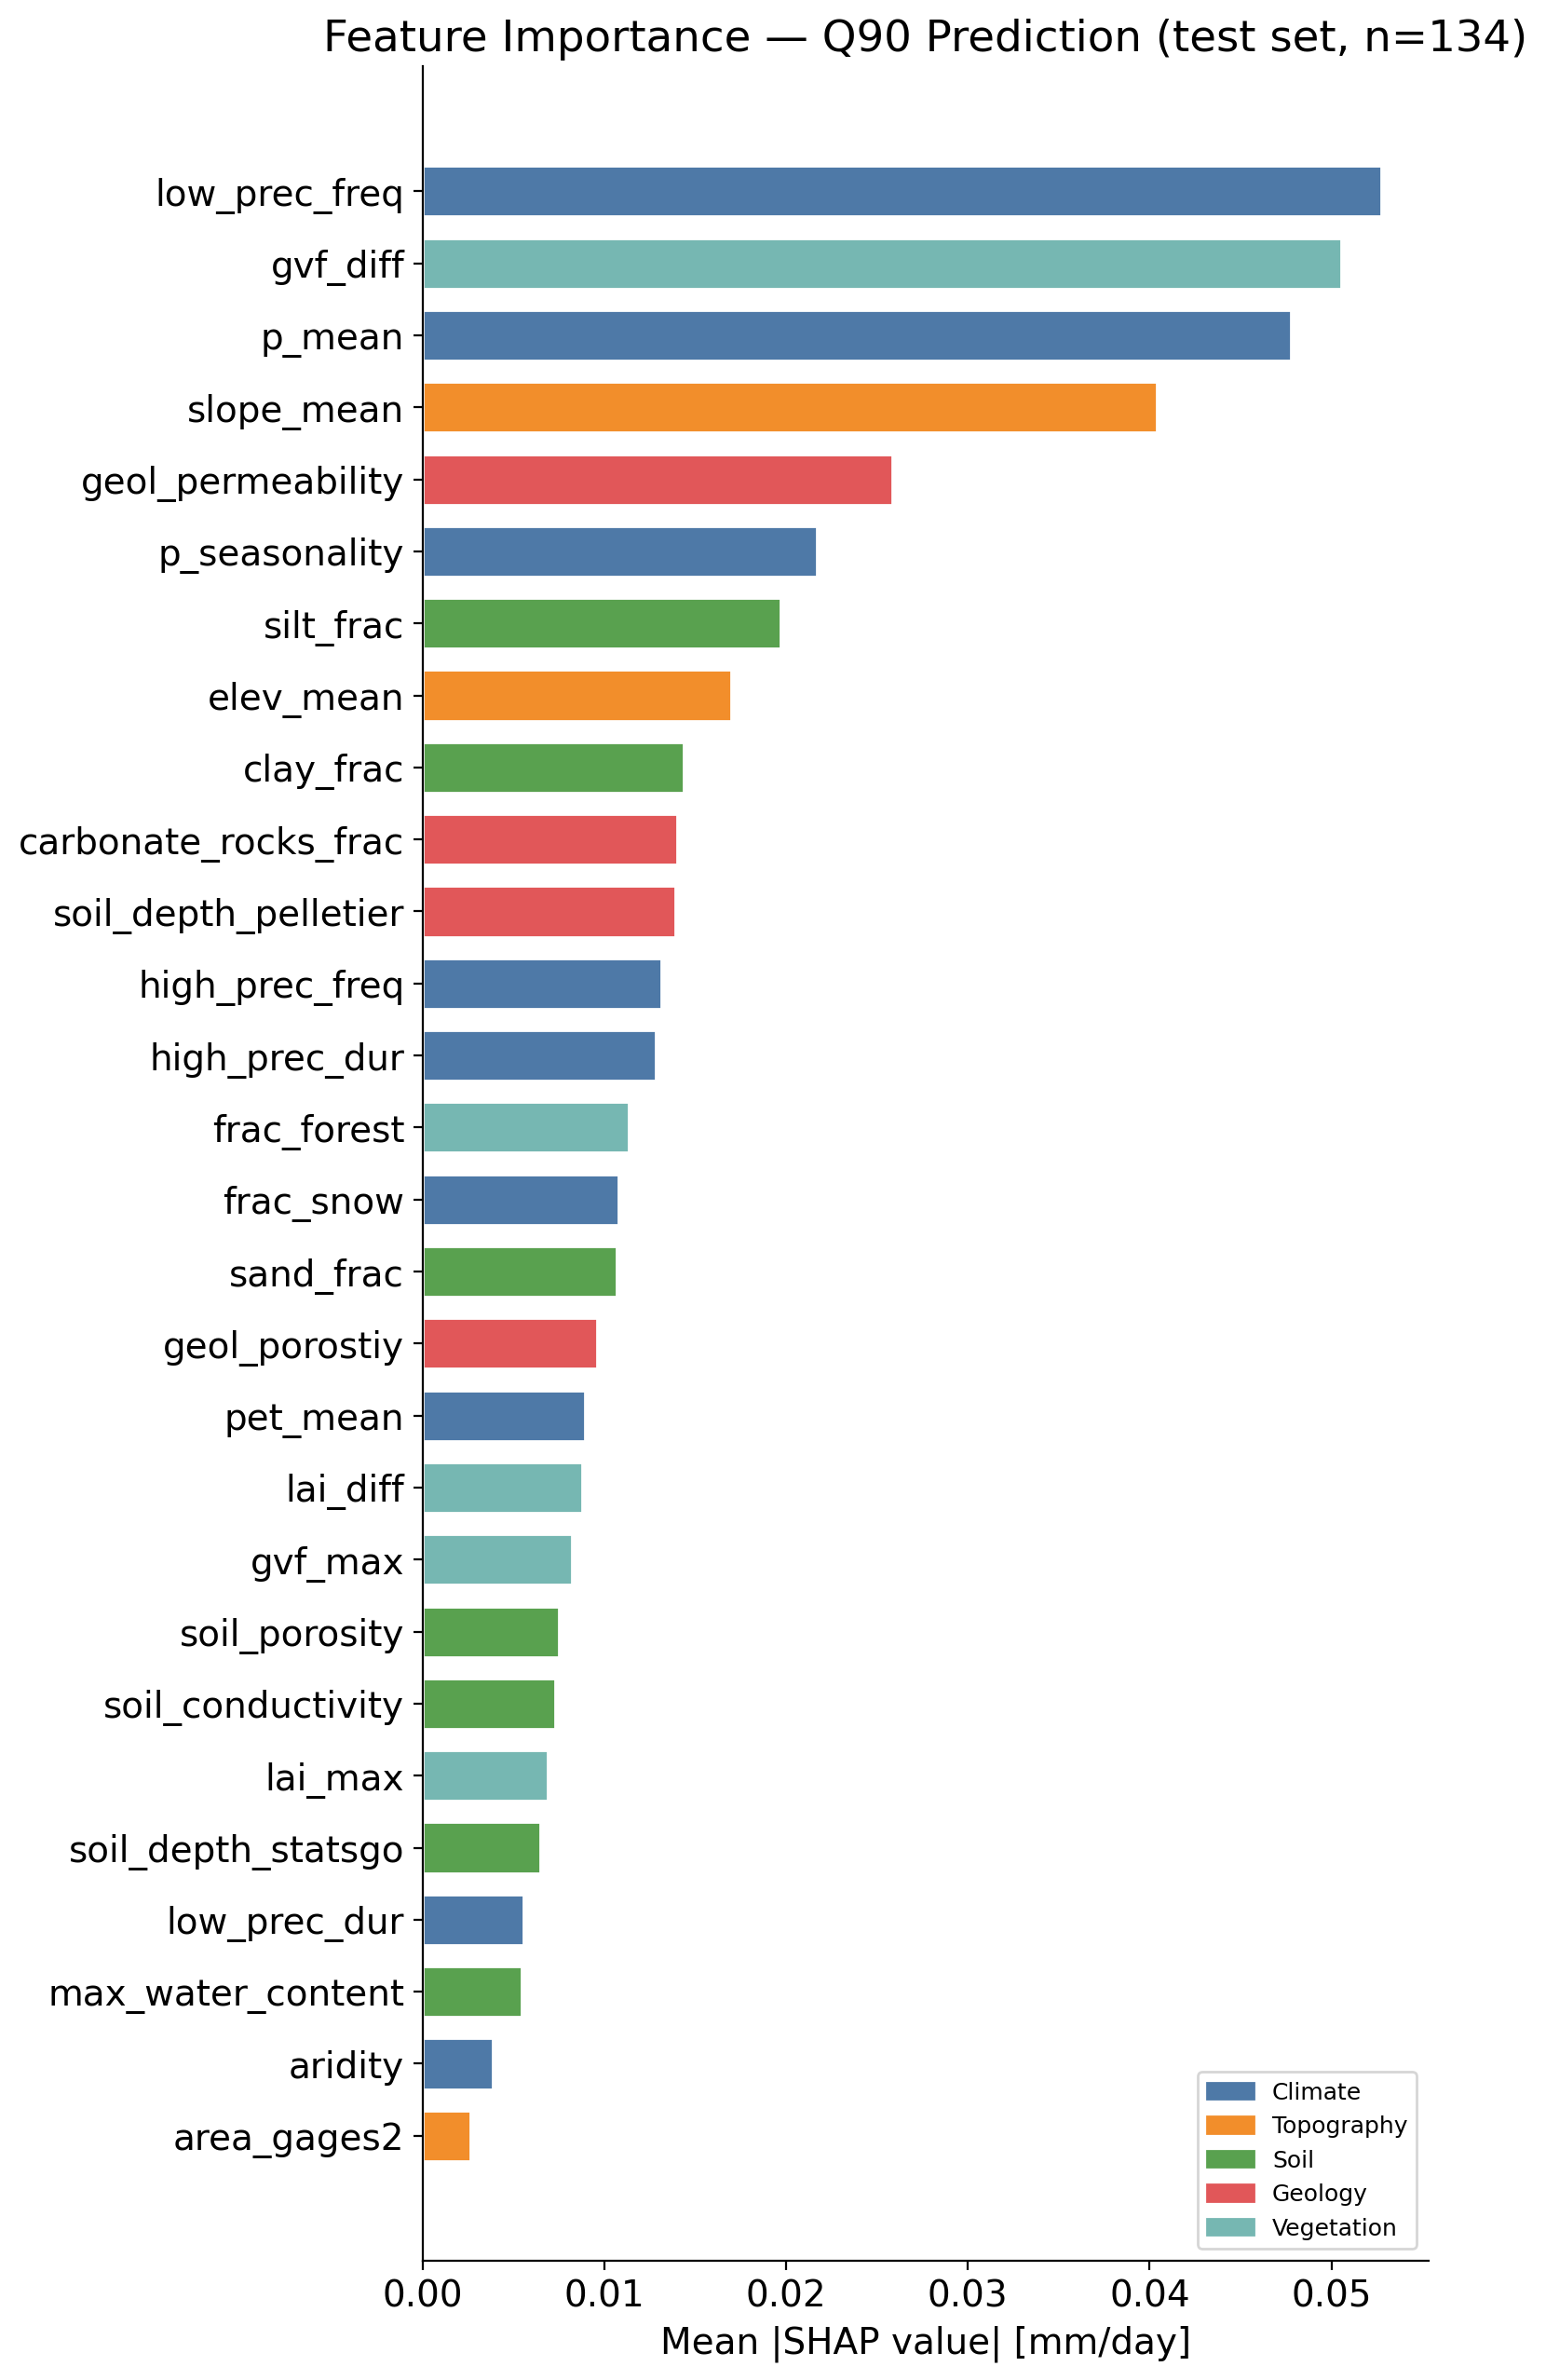

In [8]:
mean_abs = np.abs(sv).mean(axis=0)
order    = np.argsort(mean_abs)

feat_colors = [GROUP_COLORS[feat_group[feature_cols[i]]] for i in order]

fig, ax = plt.subplots(figsize=(8, 13))
bars = ax.barh([feature_cols[i] for i in order], mean_abs[order],
               color=feat_colors, edgecolor='white', height=0.7)

ax.set_xlabel('Mean |SHAP value| [mm/day]')
ax.set_title(f'Feature Importance — Q90 Prediction (test set, n={len(sv)})')

# Group legend
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in GROUP_COLORS.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout();  plt.show()

### 4.2 Beeswarm Plot

The beeswarm goes further than the bar chart: each **dot** is one test catchment. This reveals not just *which* features matter but *how* they matter — the direction and whether the relationship is monotone.


**How to read the beeswarm:**
- Features are ranked by mean |SHAP| (most important at the top)
- Each dot = one test catchment
- **x-position**: SHAP value — right of zero = raised Q90, left = lowered Q90
- **Color**: raw feature value — red = high, blue = low
- **Vertical spread (density)**: dots with similar SHAP values are jittered vertically so they don't overlap — a wide vertical band means many catchments cluster at that SHAP value


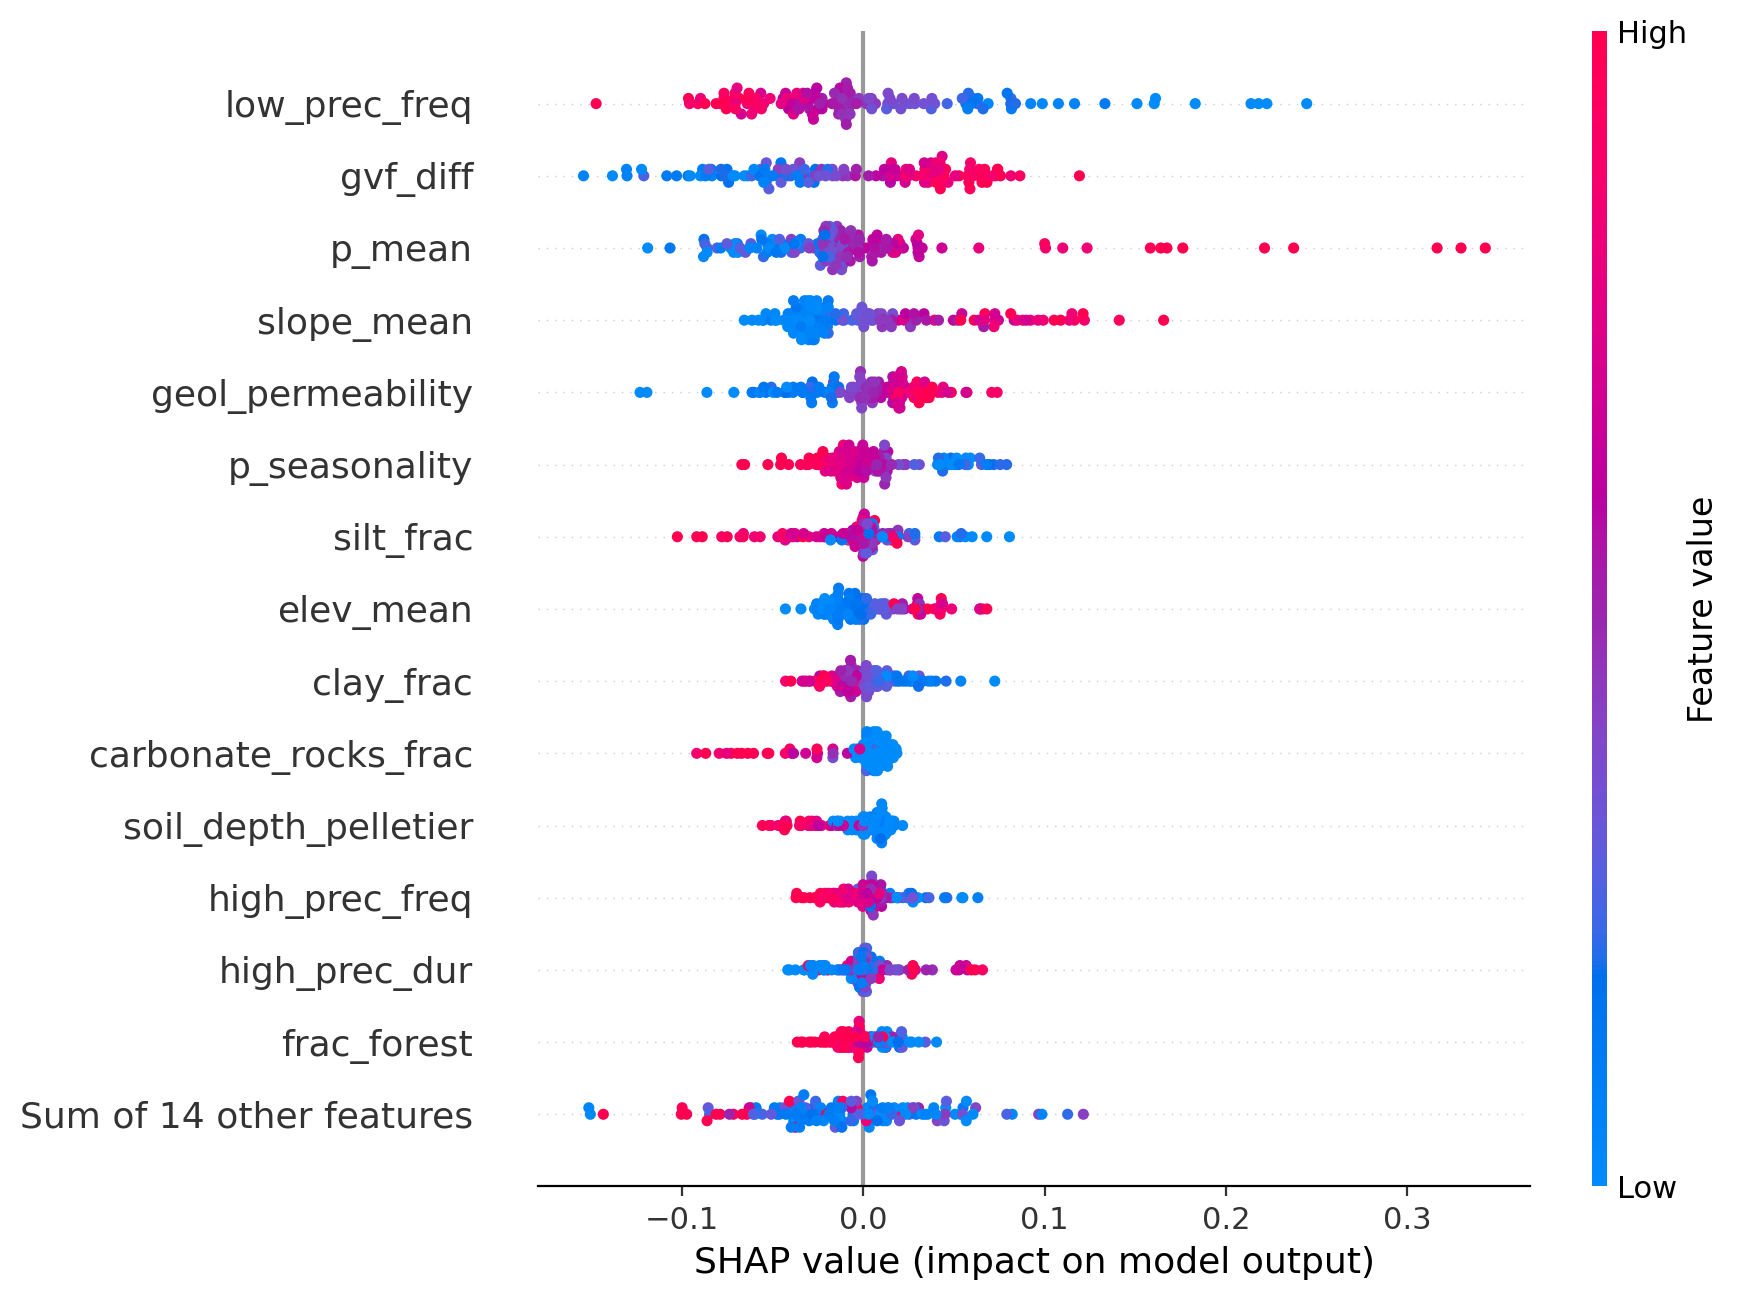

In [9]:
shap.plots.beeswarm(shap_exp, max_display=15, show=True)


> **Hydrological interpretation** (based on feature–SHAP correlations):
slowly release water, sustaining baseflow during dry periods despite the presence of some fast conduit flow.
> - **`frac_forest`**: High forest cover consistently **increases** Q90 — forests promote soil infiltration and groundwater recharge, sustaining baseflow during low-flow periods.

---
## Part 5 — Local Explanations

A **waterfall plot** breaks down the prediction for a single catchment: starting from the baseline $E[f(x)]$, each feature's SHAP value adds (positive) or subtracts (negative) to arrive at the final prediction $f(x)$. Use the dropdown to select any test catchment.

In [10]:
import ipywidgets as widgets
from IPython.display import display, clear_output

gids     = data.index[idx_test]
obs_q90  = y_test.flatten()
pred_q90 = y_pred
err_q90  = pred_q90 - obs_q90

name_col = next((c for c in ['gauge_name', 'name', 'station_nm'] if c in camels.columns), None)
def gage_name(gid):
    return camels.loc[gid, name_col] if name_col else str(gid)

wf_dropdown = widgets.Dropdown(
    options=[(f"{gid}  {gage_name(gid)}  |  obs={o:.3f}  pred={p:.3f}  err={d:+.3f}", i)
             for i, (gid, o, p, d) in enumerate(zip(gids, obs_q90, pred_q90, err_q90))],
    description='Catchment:',
    layout=widgets.Layout(width='90%'),
)
wf_out = widgets.Output()

def update_wf(change):
    i = wf_dropdown.value
    gid = gids[i]
    with wf_out:
        clear_output(wait=True)
        print(f"{gid}  {gage_name(gid)}  |  Observed = {obs_q90[i]:.4f} mm/day  |"
              f"  Predicted = {pred_q90[i]:.4f} mm/day  |  Error = {err_q90[i]:+.4f}\n")

        # Feature values table
        feat_vals = X_test[i]
        feat_df = pd.DataFrame({
            'Feature'  : feature_cols,
            'Group'    : [feat_group[f] for f in feature_cols],
            'Value'    : feat_vals,
            'SHAP'     : sv[i],
        }).sort_values('SHAP', key=abs, ascending=False)
        print(feat_df.to_string(index=False, float_format=lambda x: f'{x:+.4f}'))
        print()

        shap.plots.waterfall(shap_exp[i], max_display=12, show=True)

wf_dropdown.observe(update_wf, names='value')
display(wf_dropdown, wf_out)
update_wf(None)

Dropdown(description='Catchment:', layout=Layout(width='90%'), options=(('10172700  Vernon Creek Near Vernon, …

Output()

---
## Part 6 — Dependence Plots

Each panel shows **two features** on the axes, colored by the **SHAP value** of the x-axis feature. This reveals interaction effects: at any point (x, y) in the plot, the color tells you how much the x-axis feature contributes to the Q90 prediction given that specific combination of both features.

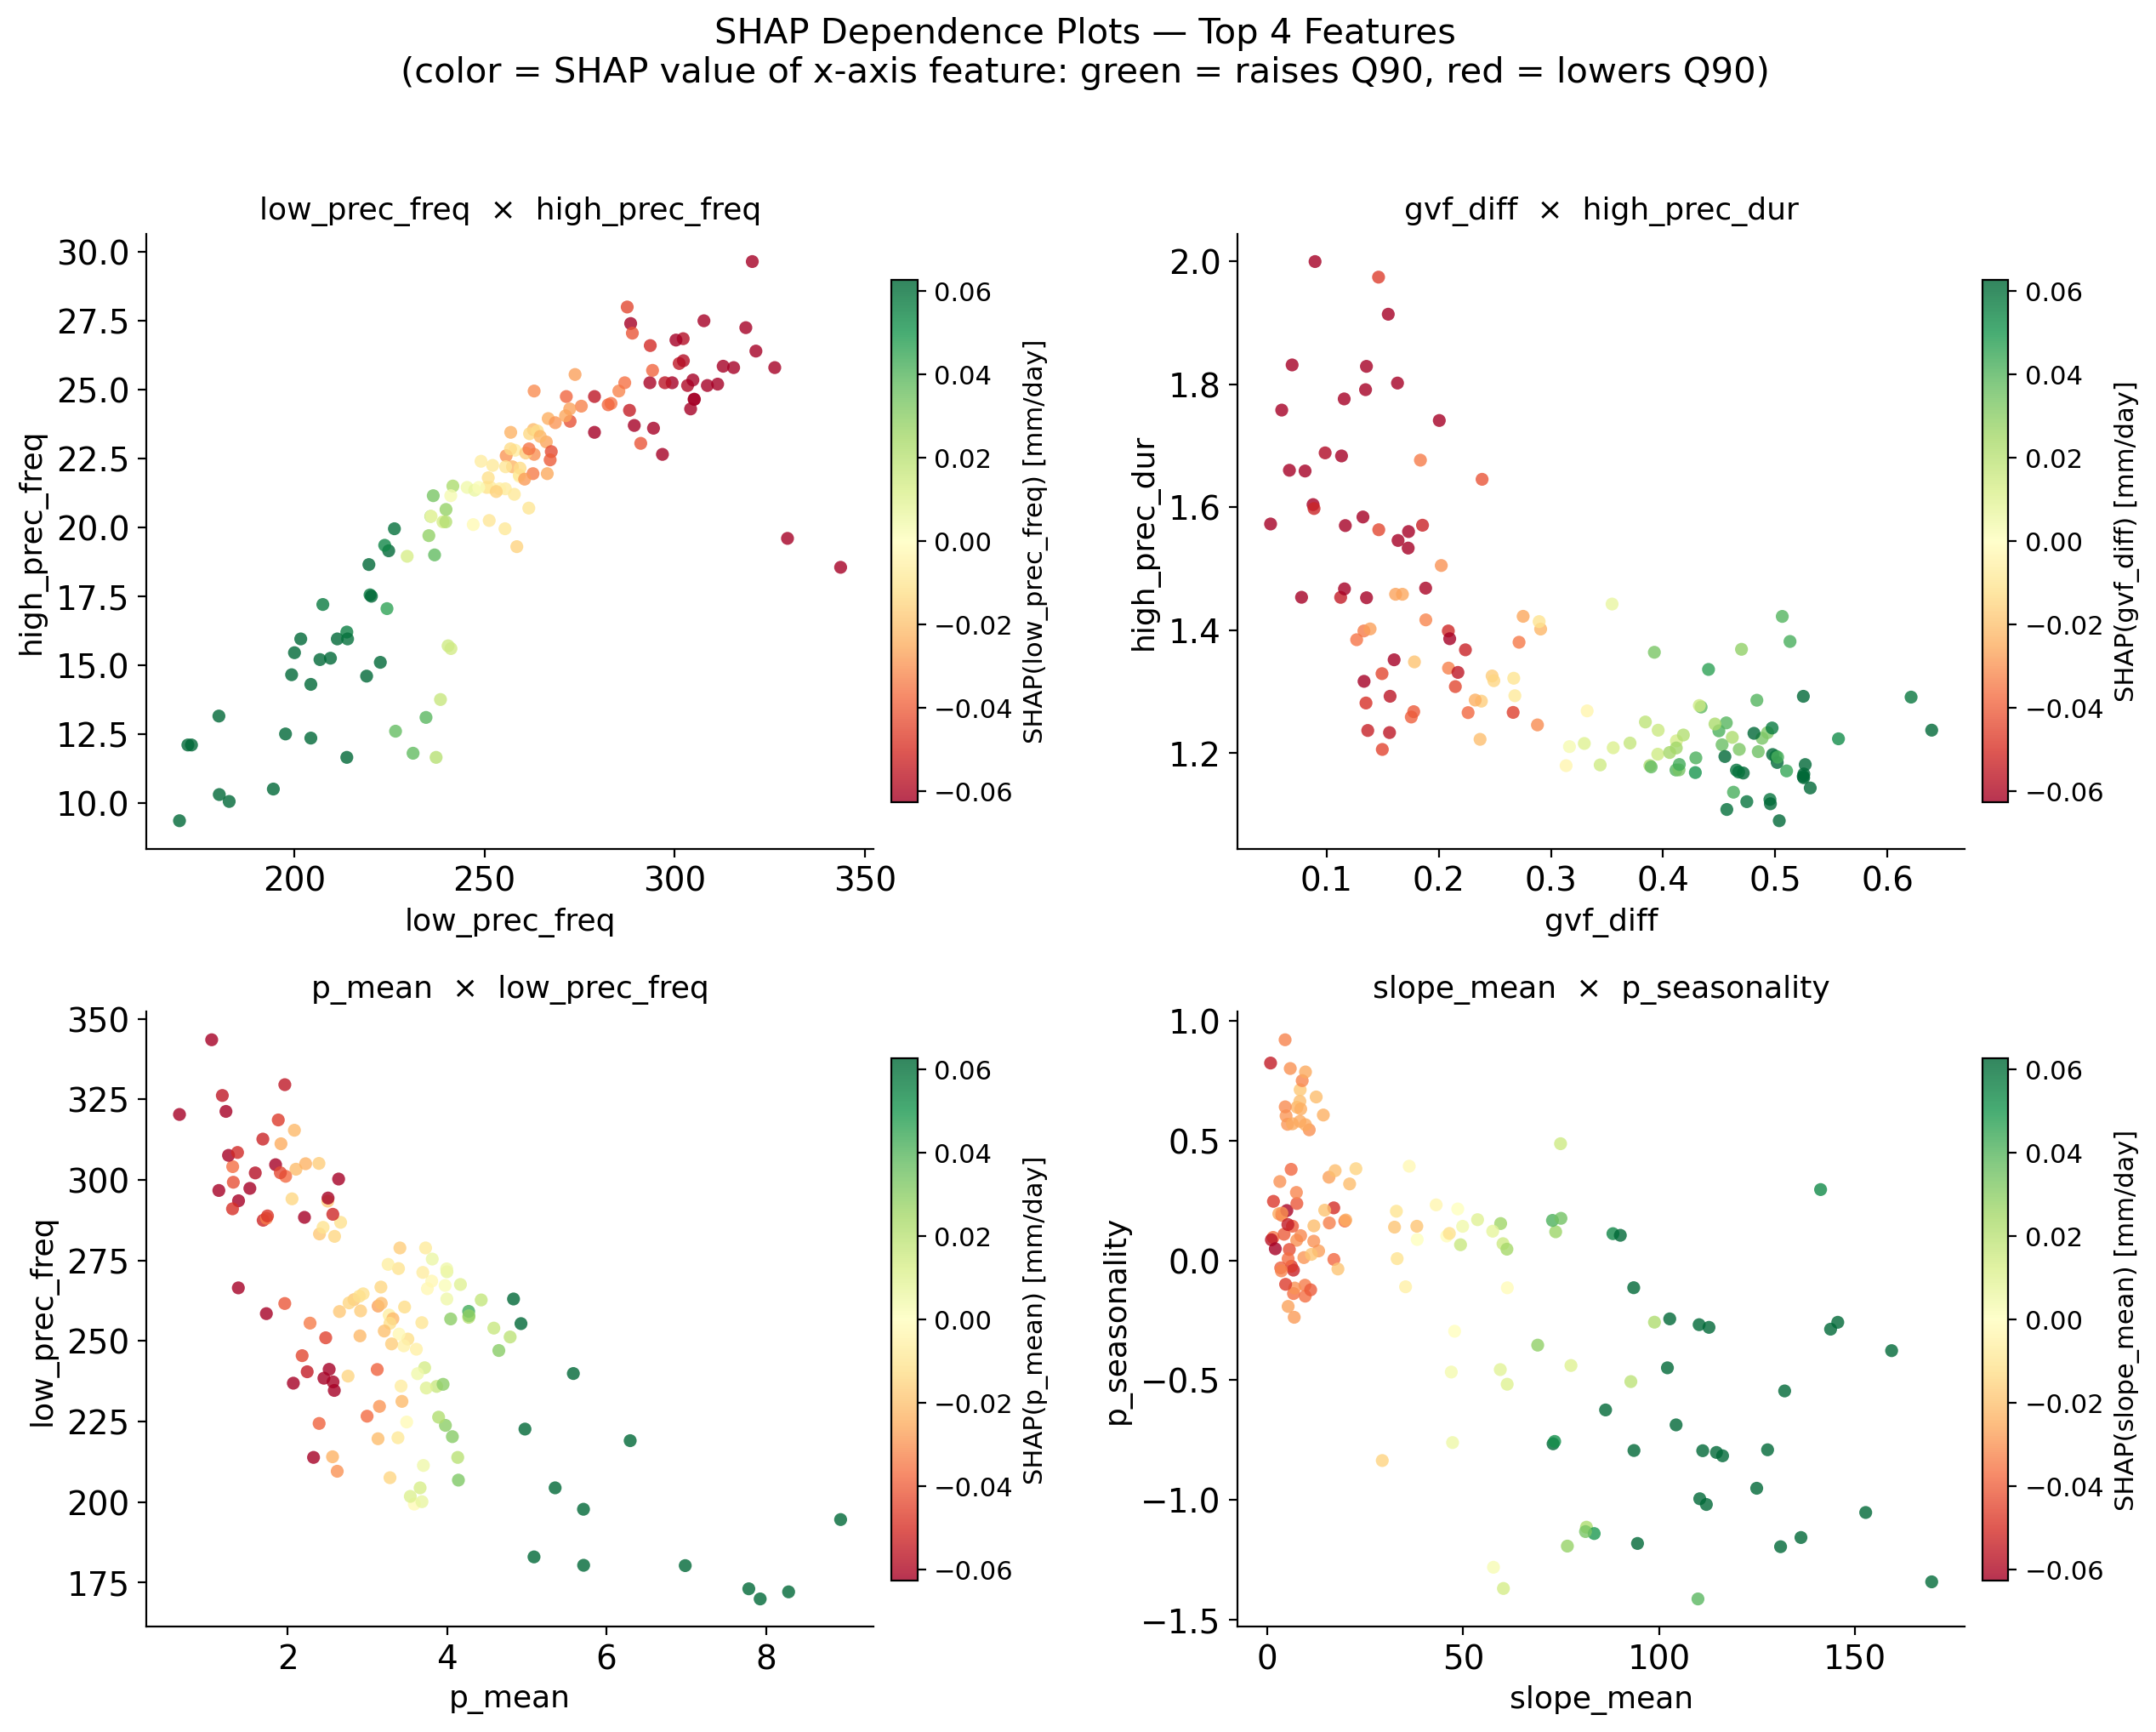

In [11]:
# Top 4 features by mean |SHAP|
top4 = [feature_cols[i] for i in np.argsort(np.abs(sv).mean(axis=0))[::-1][:4]]

# Shared symmetric colorbar limits across all panels
global_vmax = np.percentile(np.abs(sv), 95)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, feat in zip(axes.flat, top4):
    fi = feature_cols.index(feat)
    shap_f = sv[:, fi]
    feat_v = X_test[:, fi]

    # Auto-pick interaction feature (highest |corr| between SHAP_feat and other feature values)
    corrs = [abs(np.corrcoef(shap_f, X_test[:, j])[0, 1])
             if j != fi else 0 for j in range(len(feature_cols))]
    inter_i    = int(np.argmax(corrs))
    inter_v    = X_test[:, inter_i]
    inter_name = feature_cols[inter_i]

    sc = ax.scatter(feat_v, inter_v, c=shap_f, cmap='RdYlGn',
                    vmin=-global_vmax, vmax=global_vmax,
                    s=30, alpha=0.8, edgecolors='none')
    cb = plt.colorbar(sc, ax=ax, label=f'SHAP({feat}) [mm/day]', shrink=0.85, pad=0.02)
    cb.ax.tick_params(labelsize=11)
    cb.set_label(f'SHAP({feat}) [mm/day]', fontsize=11)

    ax.set_xlabel(feat, fontsize=13)
    ax.set_ylabel(inter_name, fontsize=13)
    ax.set_title(f'{feat}  ×  {inter_name}', fontsize=13)

plt.suptitle('SHAP Dependence Plots — Top 4 Features\n'
             '(color = SHAP value of x-axis feature: green = raises Q90, red = lowers Q90)',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---
## Part 7 — Spatial SHAP Map

Which feature *dominates* the Q90 prediction in each catchment? We assign each catchment its `argmax(|SHAP|)` feature and color the map by feature group. This reveals the **geographic structure of hydrological controls** on low flow.

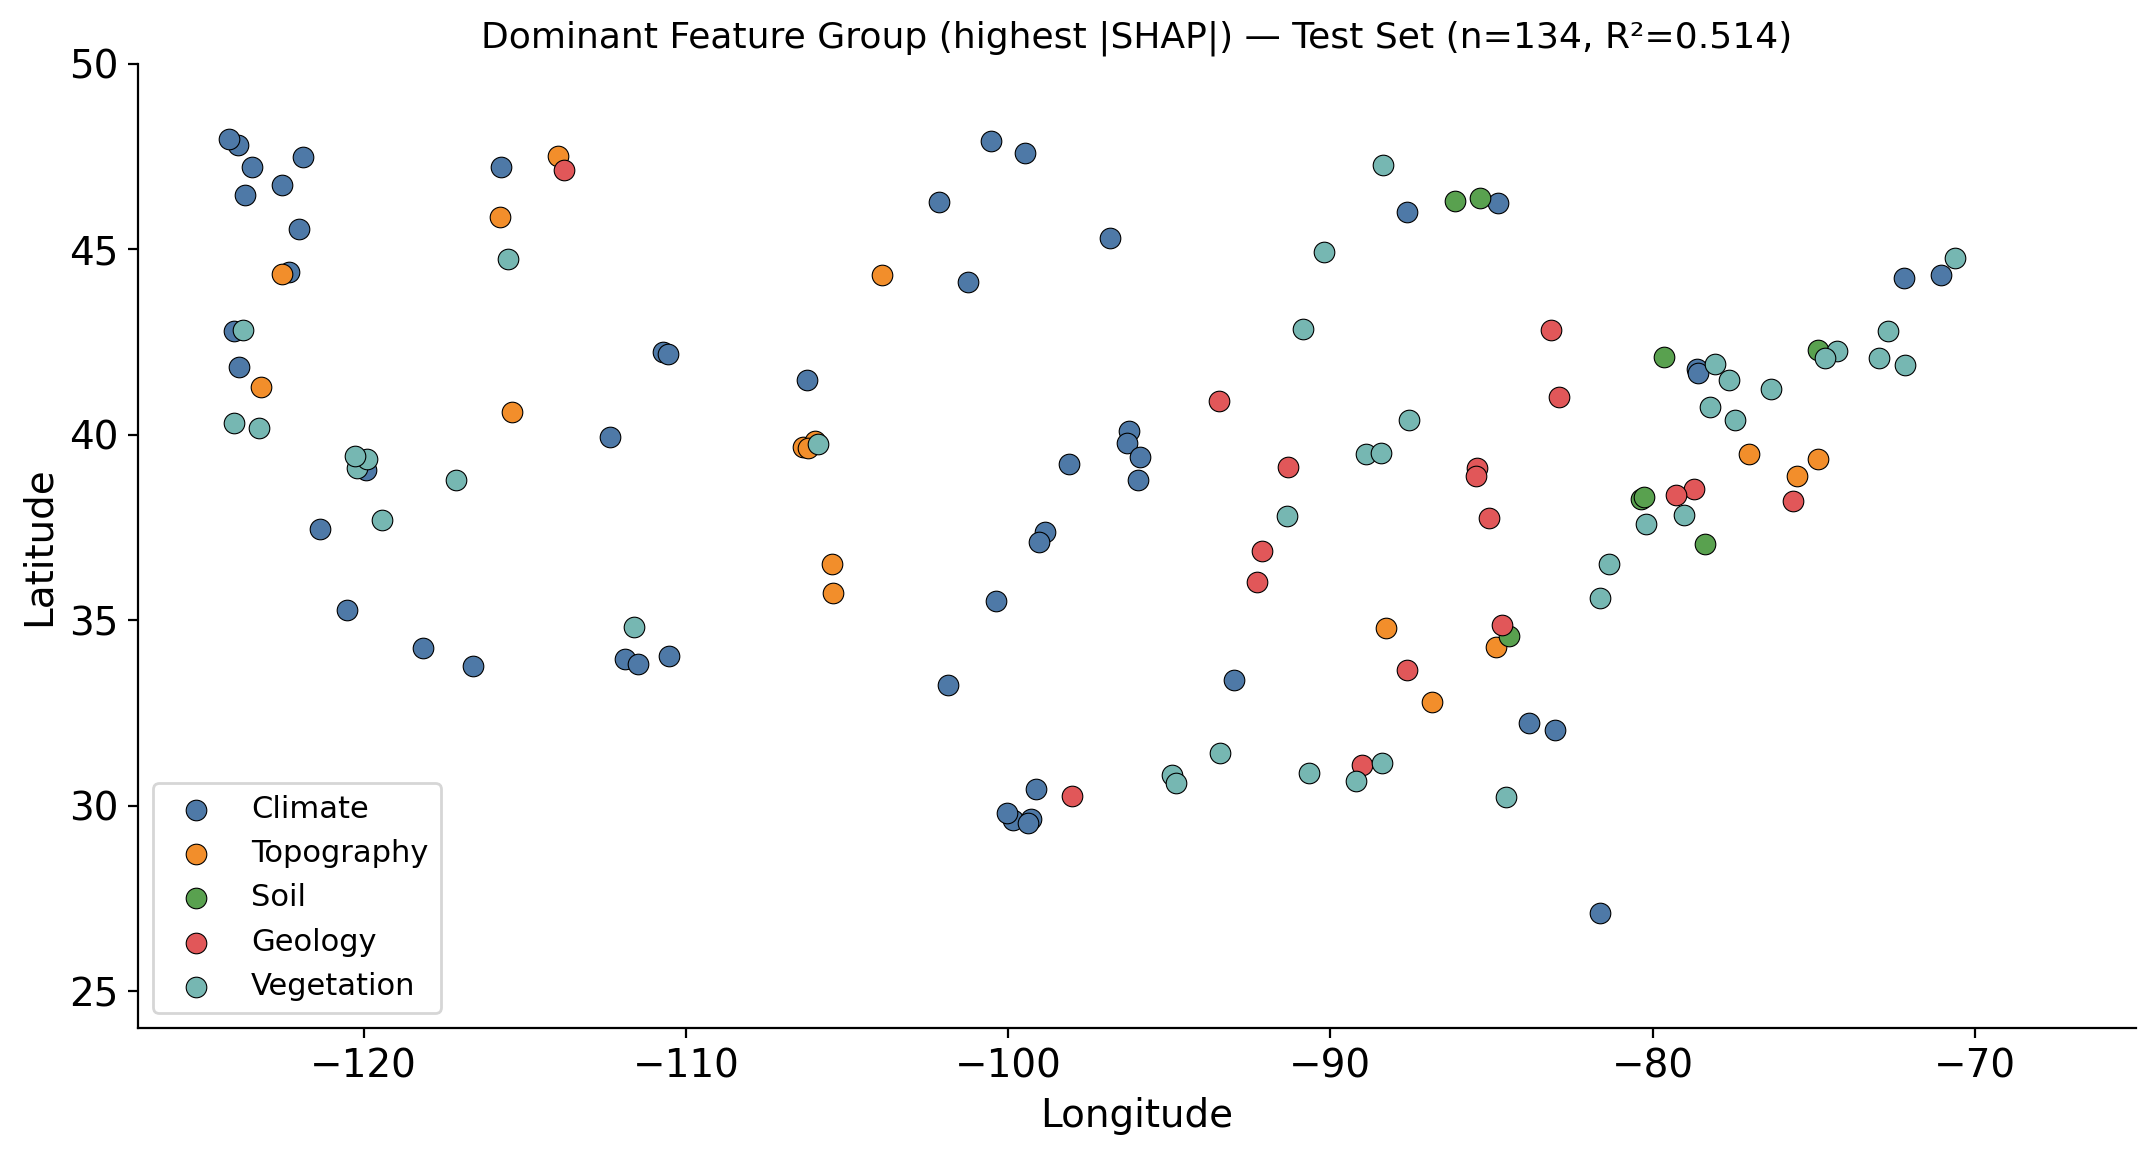


Dominant feature group counts:
  Climate          52 catchments (39%)
  Vegetation       40 catchments (30%)
  Geology          17 catchments (13%)
  Topography       17 catchments (13%)
  Soil              8 catchments (6%)


In [12]:
# Dominant feature per test catchment
dom_idx   = np.argmax(np.abs(sv), axis=1)
dom_feat  = [feature_cols[i] for i in dom_idx]
dom_group = [feat_group[f] for f in dom_feat]

cent           = camels.geometry.centroid
test_gauge_ids = data.index[idx_test]
lx = cent.loc[test_gauge_ids].x.values
ly = cent.loc[test_gauge_ids].y.values

fig, ax = plt.subplots(figsize=(11, 6))

for group, color in GROUP_COLORS.items():
    mask = np.array(dom_group) == group
    if mask.any():
        ax.scatter(lx[mask], ly[mask], c=color, s=55,
                   edgecolors='k', lw=0.4, label=group, zorder=3)

ax.set_xlim(-127, -65);  ax.set_ylim(24, 50)
ax.set_xlabel('Longitude');  ax.set_ylabel('Latitude')
ax.set_title(f'Dominant Feature Group (highest |SHAP|) — Test Set (n={len(lx)}, R²={r2:.3f})',
             fontsize=13)
ax.legend(fontsize=11, loc='lower left')
plt.tight_layout();  plt.show()

from collections import Counter
group_counts = Counter(dom_group)
print("\nDominant feature group counts:")
for g, n in sorted(group_counts.items(), key=lambda x: -x[1]):
    print(f"  {g:<15} {n:3d} catchments ({n/len(dom_group)*100:.0f}%)")

---
## Summary

### What SHAP Tells Us About Q90

| Plot | What it answers |
|------|-----------------|
| **Bar chart** | Which features matter most *on average* across all catchments? |
| **Beeswarm** | How does each feature push Q90 up or down, and for which catchments? |
| **Waterfall** | Why did the model predict *this specific value* for *this catchment*? |
| **Dependence** | What is the functional relationship between a feature and its SHAP value? |
| **Spatial map** | Do hydrological controls vary geographically? |

### Key Properties of SHAP

- **Efficiency**: all SHAP values + baseline = final prediction (exact attribution, no residual)
- **Direction**: positive SHAP = feature increased Q90; negative = decreased it
- **Units**: SHAP values are in the same units as the prediction [mm/day]
- **Model-agnostic in principle**: the same interpretation framework applies to Random Forests, linear models, or any black-box

**Next:** `02_LSTM.ipynb` — moving from static catchment attributes to sequential streamflow prediction with recurrent neural networks.